# Data Preparation

In [4]:
# Mengimpor library Pandas untuk manipulasi data berbentuk tabel (dataframe)
import pandas as pd

# Mengimpor library Numpy untuk operasi matematika dan pengolahan array/matriks
import numpy as np

# Mengimpor library Seaborn untuk membuat visualisasi data statistik yang menarik
import seaborn as sns

# Mengimpor modul Pyplot dari Matplotlib untuk membuat grafik dan kustomisasi plot
import matplotlib.pyplot as plt


Mengimpor library yang diperlukan dalam analisis data, yaitu pandas untuk pengolahan data, numpy untuk perhitungan numerik, serta seaborn dan matplotlib untuk visualisasi data.

In [5]:
# Membaca file CSV bernama "House Price Prediction Dataset.csv" ke dalam variabel df (DataFrame)
df = pd.read_csv("House Price Prediction Dataset.csv")

# Menampilkan 5 baris data teratas untuk memeriksa isi kolom dan format datanya
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Kode tersebut digunakan untuk membaca file dataset berformat CSV ke dalam DataFrame menggunakan pandas, kemudian menampilkan 5 baris pertama dari data untuk melihat struktur dan isi dataset.


In [6]:
# Melihat dimensi dataset (jumlah baris dan jumlah kolom) dalam bentuk tuple (baris, kolom)
df.shape


(2000, 10)

Kode tersebut digunakan untuk melihat ukuran dataset, yaitu jumlah baris dan kolom yang terdapat dalam DataFrame.

In [7]:
# Menampilkan ringkasan informasi dataset, termasuk tipe data tiap kolom, jumlah baris, dan jumlah nilai yang terisi (non-null)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


Kode tersebut digunakan untuk menampilkan informasi umum dataset, seperti jumlah data, nama kolom, tipe data, serta jumlah nilai yang tidak kosong pada setiap kolom.

In [8]:
# Menghitung jumlah nilai kosong (NaN/null) pada setiap kolom di dalam dataset
missing_val = df.isnull().sum()

# Menampilkan hasil perhitungan jumlah nilai kosong untuk seluruh variabel/kolom
print(missing_val)


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


Kode tersebut digunakan untuk menghitung dan menampilkan jumlah nilai kosong (missing value) pada setiap kolom dalam dataset.

In [9]:
# Mencari kemunculan nilai spesifik yang sering digunakan sebagai pengganti data kosong (seperti "Unknown" atau "?") pada seluruh dataframe, lalu menjumlahkannya per kolom
df.isin(["Unknown", "NA", "N/A", "?", "None"]).sum()


,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


Kode tersebut digunakan untuk mendeteksi dan menghitung jumlah nilai tertentu (seperti "Unknown", "NA", "?", dll) yang sering digunakan sebagai pengganti data kosong pada setiap kolom dalam dataset.


In [10]:
# Mendeteksi baris yang memiliki nilai identik di seluruh kolom, kemudian menjumlahkan total baris yang duplikat tersebut
df.duplicated().sum()


np.int64(0)

In [11]:
# Menampilkan ringkasan statistik deskriptif untuk kolom-kolom numerik, seperti rata-rata, standar deviasi, nilai minimum, kuartil, dan nilai maksimum
df.describe()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [12]:
# Menampilkan ringkasan statistik untuk kolom bertipe objek (teks/kategorik), seperti jumlah nilai unik, nilai yang paling sering muncul, dan frekuensinya
df.describe(include='object')


,Location,Condition,Garage
count,2000,2000,2000
unique,4,4,2
top,Downtown,Fair,No
freq,558,521,1038


In [13]:
# Menghitung Kuartil 1 (persentil ke-25) dari kolom 'Price'
Q1 = df['Price'].quantile(0.25)

# Menghitung Kuartil 3 (persentil ke-75) dari kolom 'Price'
Q3 = df['Price'].quantile(0.75)

# Menghitung selisih antara Q3 dan Q1 untuk mendapatkan rentang interkuartil (IQR)
IQR = Q3 - Q1

# Menentukan batas bawah untuk mendeteksi outlier (di bawah Q1 - 1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR

# Menentukan batas atas untuk mendeteksi outlier (di atas Q3 + 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

# Mencari baris data yang nilai 'Price'-nya berada di luar batas bawah atau batas atas (pencilan)
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

# Menampilkan total jumlah baris yang terdeteksi sebagai outlier
print(len(outliers))


0


In [14]:
# Menghitung jumlah kemunculan (frekuensi) untuk setiap kategori unik di dalam kolom 'Condition'
# Hasilnya akan menunjukkan berapa banyak rumah yang masuk kategori 'Good', 'New', 'Old', dsb.
df['Condition'].value_counts()


,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461


In [15]:
# Menghitung frekuensi atau jumlah kemunculan setiap kategori lokasi di dalam kolom 'Location'
# Ini membantu mengetahui area mana yang paling dominan dalam dataset rumah tersebut
df['Location'].value_counts()


,count
Location,
Downtown,558
Urban,485
Suburban,483
Rural,474


In [16]:
# Menghitung jumlah kemunculan setiap jenis atau status garasi di dalam kolom 'Garage'
# Digunakan untuk mengetahui distribusi kategori garasi (misalnya: 'Yes'/'No' atau jumlah slot parkir)
df['Garage'].value_counts()


,count
Garage,
No,1038
Yes,962


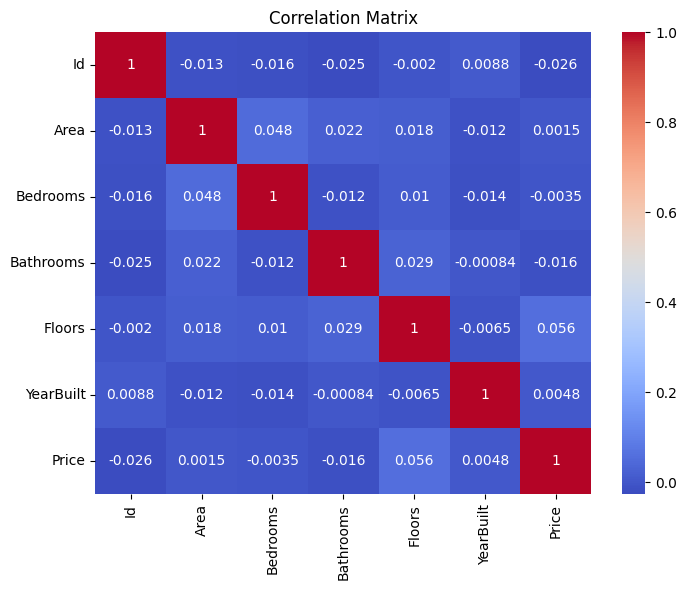

In [17]:
# Menghitung koefisien korelasi antar kolom numerik saja (menghindari error pada kolom teks)
corr_matrix = df.corr(numeric_only=True)

# Mengatur ukuran jendela grafik (lebar 8 inci, tinggi 6 inci) agar visualisasi tidak terlalu rapat
plt.figure(figsize=(8,6))

# Membuat heatmap dengan nilai korelasi yang ditampilkan di dalam kotak (annot=True)
# serta menggunakan skema warna coolwarm (biru untuk negatif, merah untuk positif)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Memberikan judul pada grafik agar mudah dipahami informasinya
plt.title('Correlation Matrix')

# Menampilkan grafik yang telah dibuat ke layar
plt.show()


In [18]:
# Menghapus kolom 'Id' dari dataframe karena tidak memiliki nilai prediktif (hanya nomor urut/identitas)
# axis=1 menentukan bahwa yang dihapus adalah kolom (bukan baris)
df = df.drop(['Id'], axis=1)


In [19]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# EDA (Eksplorasi Data Analysis)

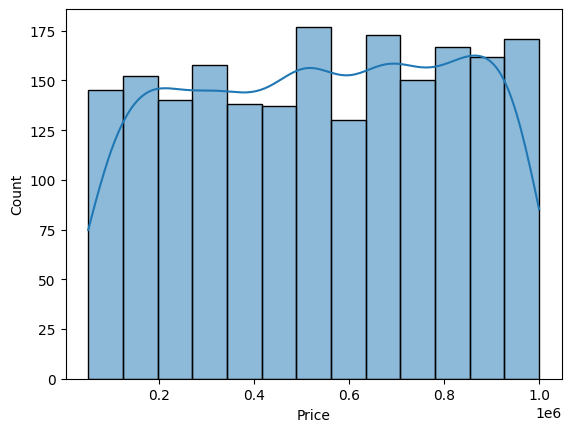

In [20]:
# Membuat grafik histogram untuk melihat persebaran data pada kolom target 'Price'
# kde=True menambahkan garis Estimasi Kepadatan Kernel untuk memperhalus bentuk distribusi
sns.histplot(df['Price'], kde=True)

# Menampilkan grafik ke layar
plt.show()


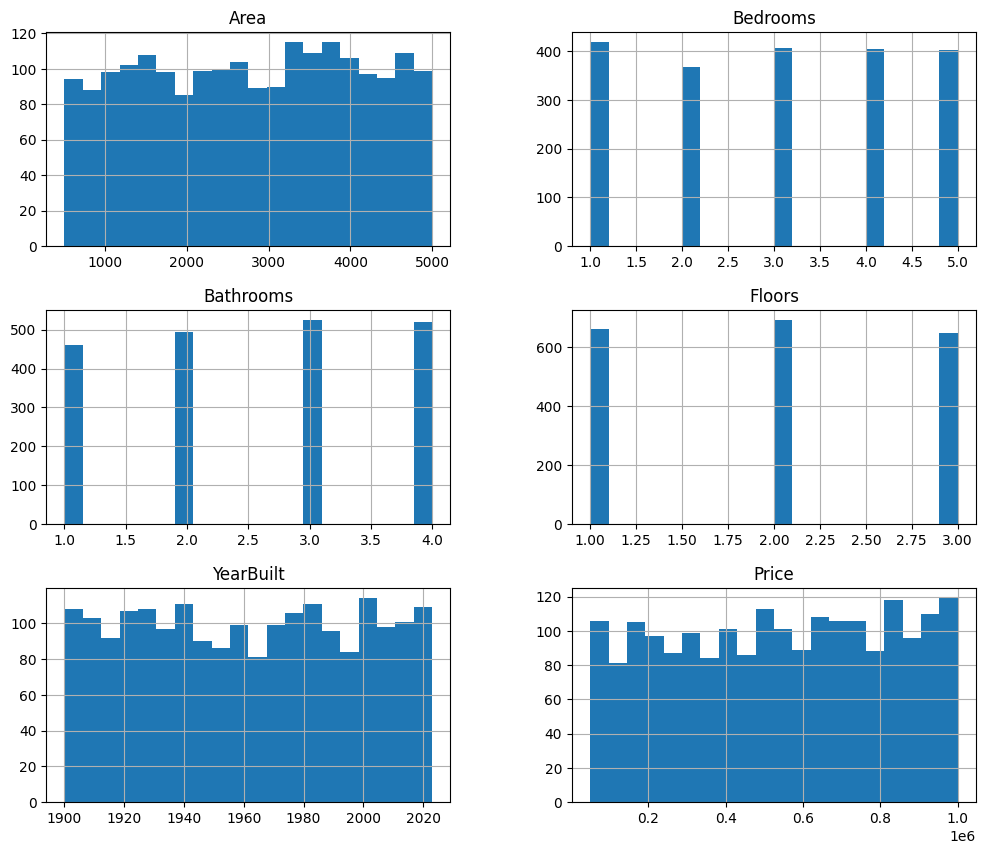

In [21]:
# Membuat grafik histogram untuk seluruh kolom numerik dalam dataframe secara sekaligus
# figsize=(12,10) mengatur ukuran total jendela grafik agar tidak saling bertumpuk
# bins=20 membagi data ke dalam 20 kelompok batang untuk melihat detail distribusi
df.hist(figsize=(12,10), bins=20)

# Menampilkan semua grafik histogram tersebut
plt.show()


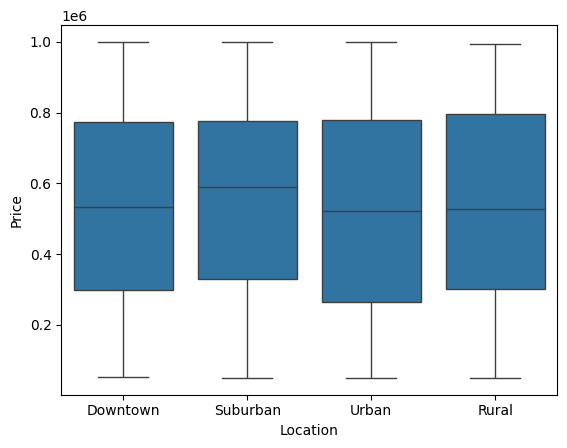

In [22]:
# Membuat grafik boxplot untuk membandingkan distribusi harga ('Price') di setiap kategori 'Location'
# Sumbu X menunjukkan nama lokasi, dan Sumbu Y menunjukkan rentang harga rumahnya
sns.boxplot(x='Location', y='Price', data=df)

# Menampilkan grafik ke layar
plt.show()


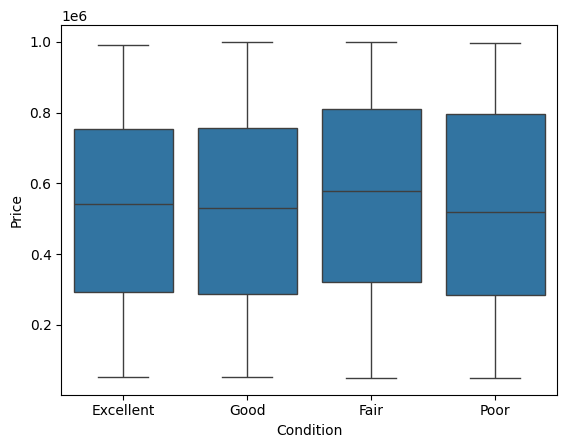

In [23]:
# Membuat grafik boxplot untuk melihat hubungan antara kategori 'Condition' (kondisi rumah) dengan 'Price' (harga)
# Membantu memvisualisasikan bagaimana kondisi rumah memengaruhi nilai jual dan sebaran harganya
sns.boxplot(x='Condition', y='Price', data=df)

# Menampilkan grafik ke layar
plt.show()


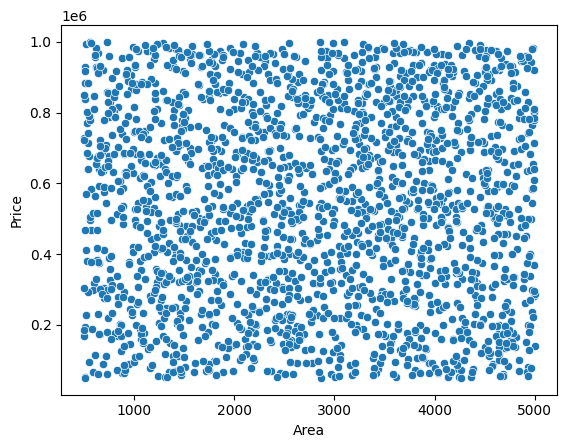

In [24]:
# Membuat grafik scatter plot (titik-titik) untuk melihat korelasi antara luas 'Area' (Sumbu X) dan 'Price' (Sumbu Y)
# Digunakan untuk melihat apakah semakin luas area, harga rumah juga cenderung naik secara linear
sns.scatterplot(x='Area', y='Price', data=df)

# Menampilkan grafik ke layar
plt.show()


# Data Preprocessing

## 1. Pembagian Data

In [25]:
# Mengimpor fungsi train_test_split dari library Scikit-learn untuk membagi data
from sklearn.model_selection import train_test_split

# Menentukan variabel independen (X) dengan mengambil semua kolom kecuali 'Price'
X = df.drop('Price', axis=1)

# Menentukan variabel target (y) yaitu kolom 'Price' yang ingin diprediksi
y = df['Price']

# Membagi data menjadi kumpulan data latih (train) dan data uji (test)
# test_size=0.2 berarti 20% data digunakan untuk pengujian, 80% untuk pelatihan
# random_state=42 digunakan agar hasil pembagian data tetap sama (konsisten) setiap kali kode dijalankan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
# Menampilkan dimensi (jumlah baris dan kolom) data fitur yang digunakan untuk melatih model (80% data)
print(X_train.shape)

# Menampilkan dimensi data fitur yang digunakan untuk menguji model (20% data)
print(X_test.shape)

# Menampilkan jumlah baris pada data target (harga) untuk pelatihan
print(y_train.shape)

# Menampilkan jumlah baris pada data target (harga) untuk pengujian
print(y_test.shape)


(1600, 8)
(400, 8)
(1600,)
(400,)


## 2. Encoding fitur kategorikal

In [27]:
# Mengubah data kategorikal biner pada kolom 'Garage' di data latih (X_train)
# menjadi angka: 'No' menjadi 0 dan 'Yes' menjadi 1 agar bisa diproses algoritma
X_train['Garage'] = X_train['Garage'].map({'No': 0, 'Yes': 1})

# Melakukan hal yang sama pada data uji (X_test) untuk menjaga konsistensi format data
X_test['Garage'] = X_test['Garage'].map({'No': 0, 'Yes': 1})


In [28]:
# Membuat kamus (dictionary) untuk menentukan urutan tingkatan kondisi rumah dari yang terendah ke tertinggi
condition_mapping = {
    'Poor': 0,      # Memberikan nilai 0 untuk kondisi paling rendah
    'Fair': 1,      # Memberikan nilai 1 untuk kondisi cukup
    'Good': 2,      # Memberikan nilai 2 untuk kondisi baik
    'Excellent': 3  # Memberikan nilai 3 untuk kondisi sangat baik
}

# Menerapkan pemetaan (mapping) tersebut ke kolom 'Condition' pada data latih (X_train)
X_train['Condition'] = X_train['Condition'].map(condition_mapping)

# Menerapkan pemetaan yang sama ke kolom 'Condition' pada data uji (X_test) agar model tetap konsisten
X_test['Condition'] = X_test['Condition'].map(condition_mapping)


In [29]:
from sklearn.preprocessing import OneHotEncoder

# 3. Nominal (Location)
# Membuat objek encoder; drop='first' untuk menghindari jebakan multikolinieritas (dummy variable trap)
# handle_unknown='ignore' agar tidak error jika ada lokasi baru di data uji yang tidak ada di data latih
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Mempelajari kategori di data latih dan langsung mengubahnya menjadi matriks angka
X_train_loc = encoder.fit_transform(X_train[['Location']])
# Mengubah data lokasi di data uji berdasarkan kategori yang sudah dipelajari dari data latih
X_test_loc = encoder.transform(X_test[['Location']])

# Mendapatkan nama kolom baru hasil encoding (misalnya: Location_Suburb, Location_Urban, dll)
loc_columns = encoder.get_feature_names_out(['Location'])

# Mengonversi hasil encoding kembali menjadi DataFrame dengan nama kolom dan index yang sesuai
X_train_loc = pd.DataFrame(X_train_loc, columns=loc_columns, index=X_train.index)
X_test_loc = pd.DataFrame(X_test_loc, columns=loc_columns, index=X_test.index)

# Menghapus kolom 'Location' asli yang masih berbentuk teks dari dataset utama
X_train = X_train.drop(columns=['Location'])
X_test = X_test.drop(columns=['Location'])

# Menggabungkan kembali dataframe utama dengan kolom-kolom baru hasil One-Hot Encoding
X_train = pd.concat([X_train, X_train_loc], axis=1)
X_test = pd.concat([X_test, X_test_loc], axis=1)


In [30]:
# Menampilkan 5 baris pertama dari data fitur (X_train) setelah semua proses encoding selesai
# Digunakan untuk memastikan semua kolom sudah berubah menjadi angka dan kolom One-Hot Encoding sudah tergabung dengan benar
X_train.head()


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Location_Rural,Location_Suburban,Location_Urban
968,4483,4,4,3,1933,3,0,0.0,0.0,1.0
240,1062,3,3,1,1970,2,0,0.0,0.0,0.0
819,1422,3,4,1,1993,2,1,0.0,0.0,1.0
692,2658,2,3,1,1972,0,1,1.0,0.0,0.0
420,3286,2,4,1,1981,3,1,1.0,0.0,0.0


In [31]:
# Menghitung jumlah kemunculan nilai 0 dan 1 pada kolom 'Garage' setelah proses encoding
# Digunakan untuk memastikan bahwa pemetaan 'No' -> 0 dan 'Yes' -> 1 telah berhasil diterapkan sepenuhnya
X_train['Garage'].value_counts()


,count
Garage,
0,841
1,759


In [32]:
# Menghitung jumlah kemunculan nilai numerik (0, 1, 2, 3) pada kolom 'Condition' setelah proses ordinal encoding
# Digunakan untuk memverifikasi bahwa tingkatan kondisi rumah sudah berubah dari teks menjadi skala angka yang benar
X_train['Condition'].value_counts()


,count
Condition,
1,423
0,410
3,400
2,367


In [33]:
# Mencari dan menampilkan 5 baris pertama hanya untuk kolom-kolom yang mengandung kata 'Location'
# Ini memudahkan Anda memeriksa apakah kolom baru hasil One-Hot Encoding sudah terbentuk dan berisi nilai 0 atau 1
X_train.filter(like='Location').head()


,Location_Rural,Location_Suburban,Location_Urban
968,0.0,0.0,1.0
240,0.0,0.0,0.0
819,0.0,0.0,1.0
692,1.0,0.0,0.0
420,1.0,0.0,0.0


## 3. Normalisasi / Scaling (Menyamakan skala fitur supaya tidak ada yang “mendominasi” model)
Apakah semua model butuh scaling? Tidak ✔️ Butuh scaling:

Linear Regression
Ridge / Lasso
KNN
SVM
❌ Tidak wajib:

Decision Tree
Random **Forest**

In [34]:
# Menampilkan tipe data dari setiap kolom yang ada di dalam dataframe X_train
# Digunakan untuk memastikan seluruh fitur sudah bertipe angka (int64 atau float64)
# dan tidak ada lagi tipe 'object' (teks) sebelum dimasukkan ke model machine learning
X_train.dtypes


,0
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Condition,int64
Garage,int64
Location_Rural,float64
Location_Suburban,float64
Location_Urban,float64


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Menentukan daftar kolom numerik yang memiliki rentang nilai berbeda-beda untuk diseragamkan
num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

# Inisialisasi StandardScaler untuk mengubah data agar memiliki rata-rata (mean) 0 dan standar deviasi 1
scaler = StandardScaler()

# FIT & TRANSFORM hanya pada data latih (X_train)
# fit: menghitung mean dan standar deviasi dari data latih
# transform: mengubah nilai asli menggunakan hasil perhitungan tersebut
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# TRANSFORM pada data uji (X_test)
# Hanya menggunakan hasil perhitungan (mean/std) dari data latih agar tidak terjadi kebocoran data (data leakage)
X_test[num_cols] = scaler.transform(X_test[num_cols])


# Modeling

## Linear Regression

In [36]:
# Mengimpor kelas LinearRegression dari modul linear_model di Scikit-learn
from sklearn.linear_model import LinearRegression

# Membuat objek/inisialisasi model Linear Regression
model = LinearRegression()

# Melatih model (proses training) menggunakan data fitur (X_train) dan target (y_train)
# Di tahap ini, model belajar mencari hubungan garis lurus terbaik antara fitur rumah dan harga
model.fit(X_train, y_train)


LinearRegression()

In [37]:
# Menggunakan model yang telah dilatih untuk memprediksi harga rumah pada data uji (X_test)
# Hasil prediksi ini kemudian disimpan dalam variabel y_pred untuk dibandingkan dengan harga asli (y_test)
y_pred = model.predict(X_test)


In [38]:
# Mengimpor fungsi metrik evaluasi dari library Scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menghitung MAE: Rata-rata selisih mutlak antara harga asli dan prediksi (semakin kecil semakin baik)
mae = mean_absolute_error(y_test, y_pred)

# Menghitung MSE: Rata-rata selisih kuadrat (memberikan bobot lebih besar pada kesalahan yang besar)
mse = mean_squared_error(y_test, y_pred)

# Menghitung RMSE: Akar kuadrat dari MSE untuk mengembalikan satuan nilai ke satuan asli (Rupiah/Dollar)
rmse = mse ** 0.5

# Menghitung R2 Score: Menunjukkan seberapa baik model menjelaskan variasi data (mendekati 1 = sangat baik)
r2 = r2_score(y_test, y_pred)

# Menampilkan hasil evaluasi ke layar
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 243453.00113858172
RMSE: 280057.76575275813
R2: -0.00814309997438234


In [39]:
# Menghitung korelasi antar semua kolom numerik, lalu mengambil korelasi khusus terhadap kolom 'Price'
# sort_values(ascending=False) digunakan untuk mengurutkan hasil dari korelasi positif terkuat hingga korelasi negatif
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)


,Price
Price,1.000000
Floors,0.055890
YearBuilt,0.004845
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737


In [40]:
# Menampilkan daftar nama kolom pada data latih (X_train)
print(X_train.columns)

# Menampilkan daftar nama kolom pada data uji (X_test)
# Digunakan untuk memastikan keduanya memiliki jumlah dan urutan fitur yang identik
print(X_test.columns)


Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
       'Garage', 'Location_Rural', 'Location_Suburban', 'Location_Urban'],
      dtype='object')
Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
       'Garage', 'Location_Rural', 'Location_Suburban', 'Location_Urban'],
      dtype='object')


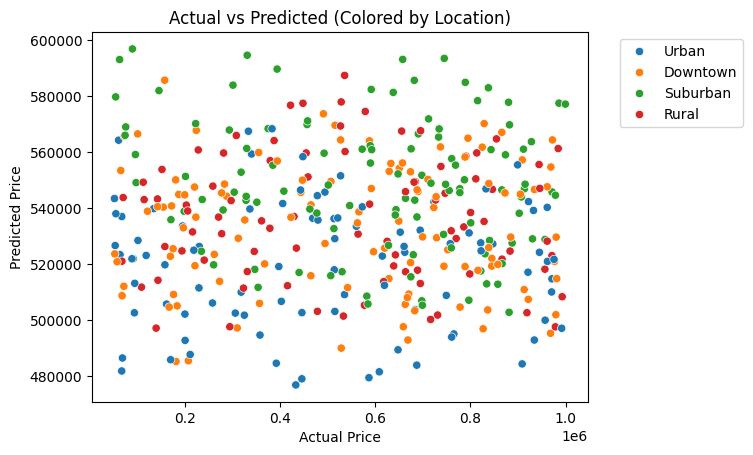

In [41]:
# Menambahkan warna berdasarkan kolom 'Location' dari data asli (df) agar lebih informatif
# Kita menggunakan index dari y_test untuk mengambil data lokasi yang sesuai
sns.scatterplot(x=y_test, y=y_pred, hue=df.loc[y_test.index, 'Location'])

# Memberikan label pada sumbu X (Harga Asli)
plt.xlabel("Actual Price")

# Memberikan label pada sumbu Y (Harga Prediksi)
plt.ylabel("Predicted Price")

# Memberikan judul grafik
plt.title("Actual vs Predicted (Colored by Location)")

# Memindahkan legenda ke luar grafik agar tidak menutupi titik data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Menampilkan grafik
plt.show()


In [42]:
# Menggunakan model untuk memprediksi harga pada data yang digunakan saat latihan (X_train)
y_train_pred = model.predict(X_train)

# Menampilkan skor R2 untuk data latih (melihat seberapa baik model menghafal data latihan)
print("Train R2:", r2_score(y_train, y_train_pred))

# Menampilkan skor R2 untuk data uji (melihat seberapa baik model memprediksi data baru yang belum pernah dilihat)
print("Test R2:", r2_score(y_test, y_pred))


Train R2: 0.007937984359026595
Test R2: -0.00814309997438234


**Analisis Linear Regression**

Model Linear Regression menunjukkan nilai R² yang sangat kecil mendekati nol pada data training dan bernilai negatif pada data testing. Hal ini menunjukkan bahwa model belum mampu menangkap hubungan antara variabel independen dan harga rumah dengan baik.

Rendahnya nilai R² mengindikasikan bahwa fitur yang digunakan belum cukup representatif atau hubungan antar variabel tidak bersifat linear.

## RandomForestRegressor

In [43]:
# Mengimpor algoritma RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Inisialisasi Model
# n_estimators=100 berarti kita menggunakan 100 pohon keputusan
# random_state agar hasil konsisten setiap kali dijalankan
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Melatih Model (Training)
# Model akan mempelajari pola dari data X_train dan target y_train
rf_model.fit(X_train, y_train)

# 3. Melakukan Prediksi
# Prediksi menggunakan data uji (X_test)
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluasi Hasil
from sklearn.metrics import r2_score, mean_absolute_error

print("--- Performa Random Forest ---")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))


--- Performa Random Forest ---
R2 Score: -0.12061014360593703
MAE: 255474.937475


**Analisis Random Forest**

Model Random Forest juga menunjukkan performa yang kurang baik dengan nilai R² negatif sebesar -0.1206. Hal ini menandakan bahwa model tidak mampu melakukan prediksi secara akurat dan bahkan lebih buruk dibandingkan dengan pendekatan rata-rata.

Nilai MAE sebesar 255474.93 menunjukkan bahwa rata-rata kesalahan prediksi masih cukup besar, sehingga hasil prediksi belum dapat diandalkan.

# Kesimpulan

Perbandingan Kedua Model

Secara umum, kedua model belum memberikan performa yang optimal dalam memprediksi harga rumah. Namun, jika dibandingkan:

* Linear Regression memiliki performa sedikit lebih baik dibandingkan Random Forest berdasarkan nilai R² yang lebih mendekati nol.
* Random Forest, meskipun secara teori lebih kompleks dan mampu menangani hubungan non-linear, pada penelitian ini belum menunjukkan keunggulannya.

**Faktor Penyebab**

Beberapa faktor yang mempengaruhi rendahnya performa kedua model antara lain:

* Data masih mengandung noise atau outlier
* Fitur yang digunakan kurang relevan
* Tidak dilakukan proses feature engineering
* Parameter model belum dioptimasi
* Dataset yang digunakan mungkin memiliki distribusi yang kompleks

Berdasarkan hasil evaluasi, dapat disimpulkan bahwa kedua model, baik Linear Regression maupun Random Forest, belum mampu memberikan hasil prediksi yang optimal. Linear Regression menunjukkan performa yang sedikit lebih baik, namun tetap belum cukup untuk digunakan sebagai model prediksi yang akurat.

Oleh karena itu, diperlukan perbaikan pada tahap preprocessing data, pemilihan fitur, serta optimasi model untuk meningkatkan kinerja prediksi.


---


# TAMBAHAN

In [46]:
# 1. Import library
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 2. Inisialisasi model
model = LinearRegression()

# 3. Training model
model.fit(X_train, y_train)

# 4. Prediksi
y_pred = model.predict(X_test)

# 5. Evaluasi
print("--- Performa Linear Regression ---")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# 6. Menampilkan Rumus Persamaan
print("\n--- Rumus Regresi Linear ---")

# Intercept (konstanta)
print("Intercept (a):", model.intercept_)

# Koefisien (b)
print("Koefisien (b):", model.coef_)


# Menampilkan rumus lengkap
rumus = "y = " + str(model.intercept_)

for i, coef in enumerate(model.coef_):
    rumus += " + (" + str(coef) + " * X" + str(i+1) + ")"

print("\nRumus Prediksi:")
print(rumus)

--- Performa Linear Regression ---
R2 Score: -0.00814309997438234
MAE: 243453.00113858172

--- Rumus Regresi Linear ---
Intercept (a): 541859.8376707988
Koefisien (b): [  -420.41094664    219.44177056 -11107.09412326  19188.60250172
   3811.41865394  -4848.24020812   2669.26509857   2265.04131137
  12514.26227327 -13169.91808797]

Rumus Prediksi:
y = 541859.8376707988 + (-420.4109466361327 * X1) + (219.44177055704722 * X2) + (-11107.094123263803 * X3) + (19188.602501717553 * X4) + (3811.41865394476 * X5) + (-4848.240208120106 * X6) + (2669.265098571042 * X7) + (2265.041311367702 * X8) + (12514.26227326545 * X9) + (-13169.91808796603 * X10)




---

